In [15]:
import os

# Create reports folder
os.makedirs('../reports', exist_ok=True)

# Check where you are
print("Current working directory:")
print(os.getcwd())

# Check if reports folder exists
print("\nReports folder exists:", os.path.exists('../reports'))

# List files in reports
print("\nFiles in reports folder:")
for f in os.listdir('../reports'):
    print(f"  → {f}")

Current working directory:
C:\Users\Yash Chavan\Data Analysis (Zomato)\notebooks

Reports folder exists: True

Files in reports folder:
  → chart1_rating_distribution.png
  → chart2_table_booking.png
  → chart3_cost_vs_rating.png
  → chart4_location_rating.png
  → chart5_cuisine_analysis.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style setup
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

df_b = pd.read_csv('../data/processed/bengaluru_cleaned.csv')
df_g = pd.read_csv('../data/processed/global_cleaned.csv')

# Recreate engineered columns from EDA
bins = [0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
labels = ['Poor', 'Below Avg', 'Average', 'Good', 'Very Good', 'Excellent']
df_b['rating_category'] = pd.cut(df_b['rate'], bins=bins, labels=labels)

df_b['cost_bracket'] = pd.cut(df_b['cost_for_two'],
                               bins=[0, 300, 600, 900, 1200, 10000],
                               labels=['Budget', 'Economy', 
                                      'Mid', 'Premium', 'Luxury'])

df_b['primary_cuisine'] = df_b['cuisines'].str.split(',').str[0].str.strip()

print("✅ Setup complete")

✅ Setup complete


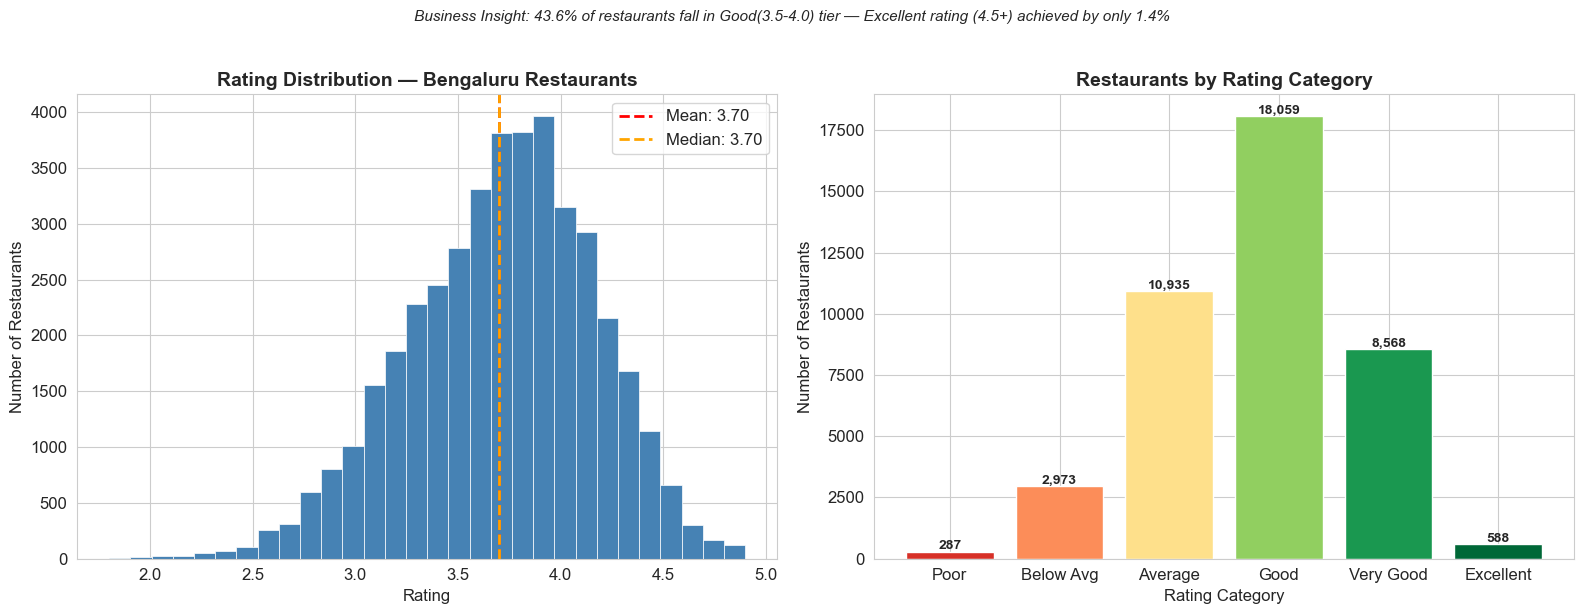

✅ Chart 1 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Histogram
axes[0].hist(df_b['rate'], bins=30, color='steelblue', 
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df_b['rate'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f"Mean: {df_b['rate'].mean():.2f}")
axes[0].axvline(df_b['rate'].median(), color='orange', 
                linestyle='--', linewidth=2, label=f"Median: {df_b['rate'].median():.2f}")
axes[0].set_title('Rating Distribution — Bengaluru Restaurants', 
                   fontweight='bold', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Restaurants')
axes[0].legend()

# Plot 2 — Category bar
category_counts = df_b['rating_category'].value_counts().sort_index()
colors = ['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850','#006837']
bars = axes[1].bar(category_counts.index, category_counts.values, 
                    color=colors, edgecolor='white')
axes[1].set_title('Restaurants by Rating Category', 
                   fontweight='bold', fontsize=14)
axes[1].set_xlabel('Rating Category')
axes[1].set_ylabel('Number of Restaurants')

# Add value labels on bars
for bar, val in zip(bars, category_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 100,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Business Insight: 43.6% of restaurants fall in Good(3.5-4.0) tier — '
             'Excellent rating (4.5+) achieved by only 1.4%',
             fontsize=11, style='italic', y=1.02)
plt.tight_layout()
plt.savefig('../reports/chart1_rating_distribution.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 1 saved")

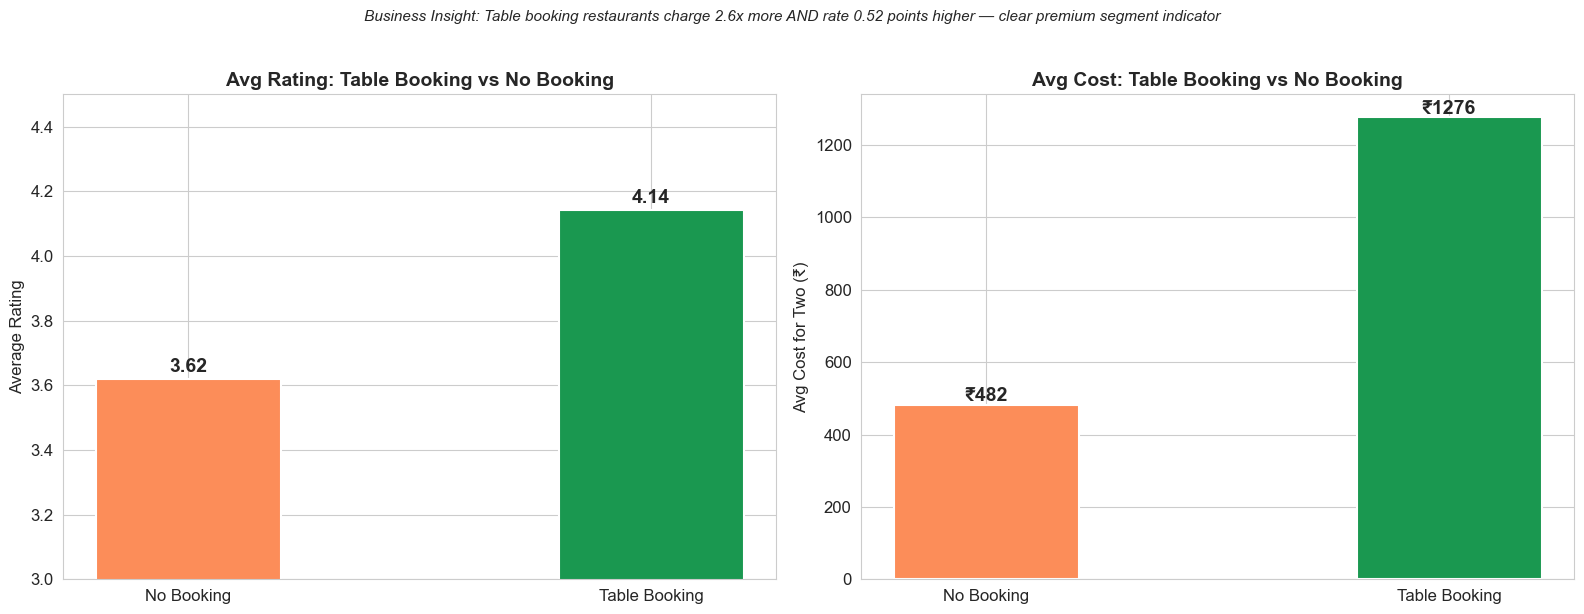

✅ Chart 2 saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Rating comparison
table_data = df_b.groupby('book_table')['rate'].mean()
labels_map = {0: 'No Booking', 1: 'Table Booking'}
table_data.index = [labels_map[i] for i in table_data.index]

bars = axes[0].bar(table_data.index, table_data.values,
                    color=['#fc8d59', '#1a9850'], width=0.4,
                    edgecolor='white', linewidth=1.5)
axes[0].set_ylim(3.0, 4.5)
axes[0].set_title('Avg Rating: Table Booking vs No Booking',
                   fontweight='bold', fontsize=14)
axes[0].set_ylabel('Average Rating')

for bar, val in zip(bars, table_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', 
                fontsize=14, fontweight='bold')

# Plot 2 — Cost comparison
cost_data = df_b.groupby('book_table')['cost_for_two'].mean()
cost_data.index = [labels_map[i] for i in cost_data.index]

bars2 = axes[1].bar(cost_data.index, cost_data.values,
                     color=['#fc8d59', '#1a9850'], width=0.4,
                     edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg Cost: Table Booking vs No Booking',
                   fontweight='bold', fontsize=14)
axes[1].set_ylabel('Avg Cost for Two (₹)')

for bar, val in zip(bars2, cost_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                f'₹{val:.0f}', ha='center',
                fontsize=14, fontweight='bold')

plt.suptitle('Business Insight: Table booking restaurants charge 2.6x more '
             'AND rate 0.52 points higher — clear premium segment indicator',
             fontsize=11, style='italic', y=1.02)
plt.tight_layout()
plt.savefig('../reports/chart2_table_booking.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 2 saved")

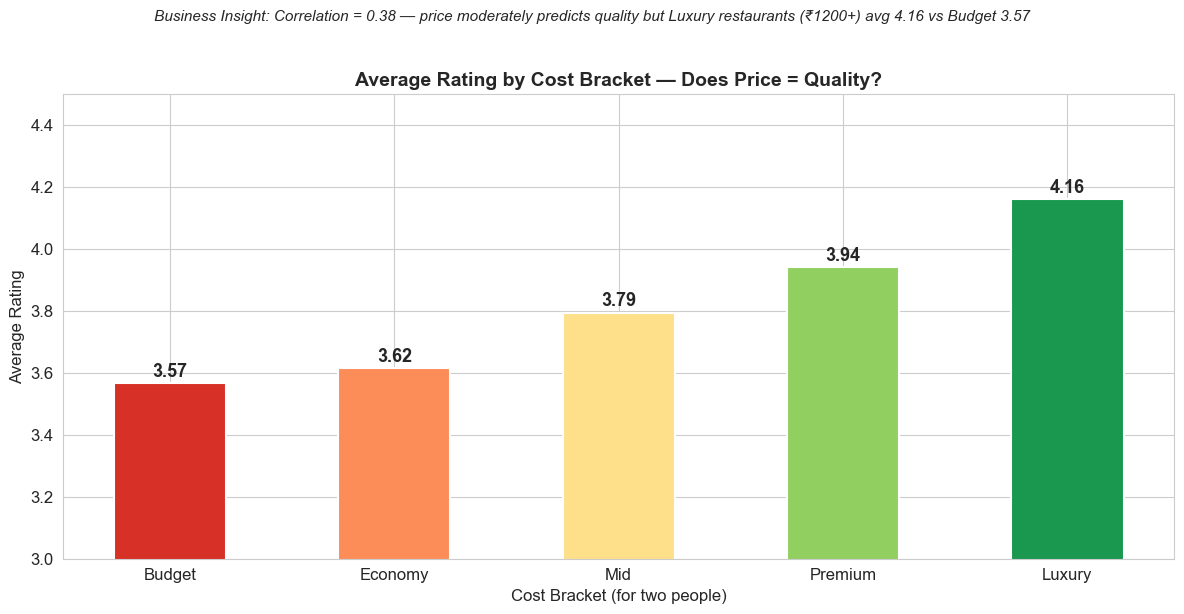

✅ Chart 3 saved


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

cost_rating = df_b.groupby('cost_bracket')['rate'].mean()
colors_cost = ['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850']

bars = ax.bar(cost_rating.index, cost_rating.values,
               color=colors_cost, edgecolor='white', 
               linewidth=1.5, width=0.5)

ax.set_ylim(3.0, 4.5)
ax.set_title('Average Rating by Cost Bracket — Does Price = Quality?',
              fontweight='bold', fontsize=14)
ax.set_xlabel('Cost Bracket (for two people)')
ax.set_ylabel('Average Rating')

for bar, val in zip(bars, cost_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.2f}', ha='center',
            fontsize=13, fontweight='bold')

plt.suptitle('Business Insight: Correlation = 0.38 — price moderately predicts '
             'quality but Luxury restaurants (₹1200+) avg 4.16 vs Budget 3.57',
             fontsize=11, style='italic', y=1.02)
plt.tight_layout()
plt.savefig('../reports/chart3_cost_vs_rating.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 3 saved")

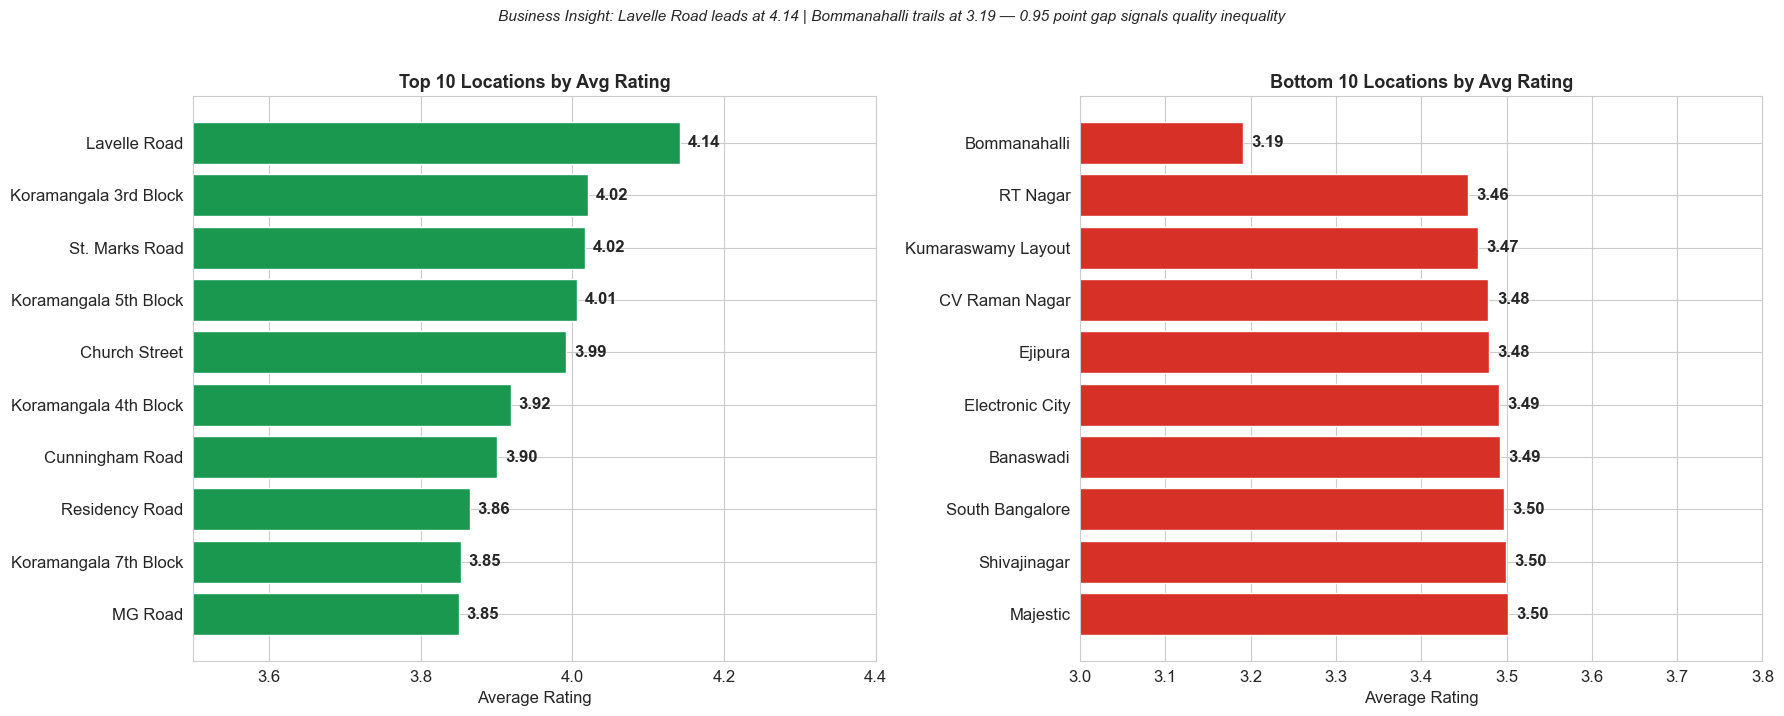

✅ Chart 4 saved


In [12]:
location_data = df_b.groupby('location').agg(
    avg_rating=('rate','mean'),
    total=('name','count')
).query('total >= 50').sort_values('avg_rating', ascending=False)

top10    = location_data.head(10)
bottom10 = location_data.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10
axes[0].barh(top10.index[::-1], top10['avg_rating'][::-1],
              color='#1a9850', edgecolor='white')
axes[0].set_title('Top 10 Locations by Avg Rating',
                   fontweight='bold', fontsize=13)
axes[0].set_xlabel('Average Rating')
axes[0].set_xlim(3.5, 4.4)
for i, (idx, row) in enumerate(top10[::-1].iterrows()):
    axes[0].text(row['avg_rating'] + 0.01, i,
                f'{row["avg_rating"]:.2f}', va='center', fontweight='bold')

# Bottom 10
axes[1].barh(bottom10.index, bottom10['avg_rating'],
              color='#d73027', edgecolor='white')
axes[1].set_title('Bottom 10 Locations by Avg Rating',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.0, 3.8)
for i, (idx, row) in enumerate(bottom10.iterrows()):
    axes[1].text(row['avg_rating'] + 0.01, i,
                f'{row["avg_rating"]:.2f}', va='center', fontweight='bold')

plt.suptitle('Business Insight: Lavelle Road leads at 4.14 | '
             'Bommanahalli trails at 3.19 — 0.95 point gap signals quality inequality',
             fontsize=11, style='italic', y=1.02)
plt.tight_layout()
plt.savefig('../reports/chart4_location_rating.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 4 saved")

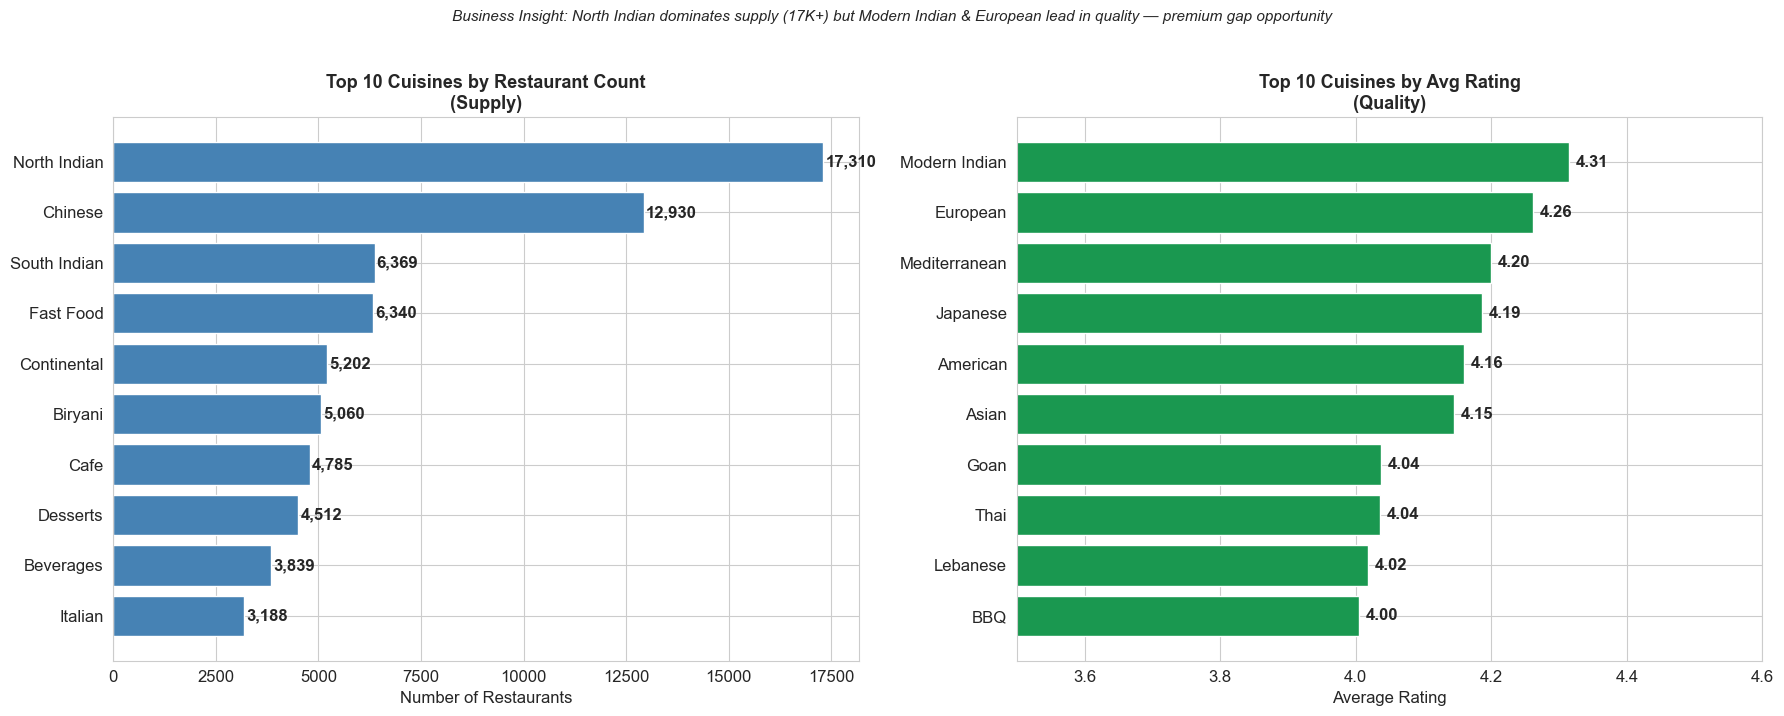

✅ Chart 5 saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Most popular cuisines
cuisine_counts = df_b['cuisines'].str.split(',').explode().str.strip()
top_cuisines = cuisine_counts.value_counts().head(10)

axes[0].barh(top_cuisines.index[::-1], top_cuisines.values[::-1],
              color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Cuisines by Restaurant Count\n(Supply)',
                   fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Restaurants')
for i, val in enumerate(top_cuisines.values[::-1]):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontweight='bold')

# Highest rated cuisines
cuisine_rating = (df_b.groupby('primary_cuisine')['rate']
                  .agg(['mean','count'])
                  .query('count >= 50')
                  .sort_values('mean', ascending=False)
                  .head(10))

axes[1].barh(cuisine_rating.index[::-1], 
              cuisine_rating['mean'][::-1],
              color='#1a9850', edgecolor='white')
axes[1].set_title('Top 10 Cuisines by Avg Rating\n(Quality)',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.5, 4.6)
for i, (idx, row) in enumerate(cuisine_rating[::-1].iterrows()):
    axes[1].text(row['mean'] + 0.01, i,
                f'{row["mean"]:.2f}', va='center', fontweight='bold')

plt.suptitle('Business Insight: North Indian dominates supply (17K+) '
             'but Modern Indian & European lead in quality — premium gap opportunity',
             fontsize=11, style='italic', y=1.02)
plt.tight_layout()
plt.savefig('../reports/chart5_cuisine_analysis.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart 5 saved")